<a href="https://colab.research.google.com/github/Sakshi281204/Data-Science/blob/main/Assingnment_Accredian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The main purpose of Exploratory Data Analysis (EDA) is to understand the dataset before building the Instructor Effectiveness model. I want to check the overall structure and quality of the data, understand the distribution of learner outcomes, engagement, and feedback metrics, and identify any important relationships between the variables.

EDA will also help me identify potential issues such as missing values, duplicate records, unusual observations, and highly correlated variables. These findings will be useful later when I define the Instructor Effectiveness Score and aggregate the batch-level data to the instructor level.


First I will load All the  required Libraries

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The path to your uploaded file in Colab
file_path = '/content/instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv'
df = pd.read_csv(file_path)
print("Dataset loaded successfully!")
display(df.head())


Dataset loaded successfully!


,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In This cell i am going tto check if there are any null values in the dataset .
What is the Shape of the dataset?
Shape means Rows * Columns present in the dataset .
then I will find total of all the required columns like Courses batheches and Insttructo , I will using nunique() function to get total of unique valuse only .
the function will not count if the value is repeated .

In [71]:
print("Dataset Shape:", df.shape)
print("\nNumber of Instructors:", df["instructor_id"].nunique())
print("Number of Courses:", df["course_id"].nunique())
print("Number of Batches:", df["batch_id"].nunique())

df.info()

Dataset Shape: (2000, 12)

Number of Instructors: 120
Number of Courses: 25
Number of Batches: 2000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   flo

By using df.info() function i got to know that tthe dataset doesn't contain any missing value

In [72]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
completion_rate,2000.0,0.602808,0.159667,0.300000,0.489260,0.603091,0.712797,0.980000
avg_score_improvement,2000.0,27.035844,5.716641,6.159240,23.124673,26.938629,30.885600,40.000000
avg_quiz_score,2000.0,77.956126,10.695618,40.386725,70.897590,78.020567,85.444286,100.000000
dropout_rate,2000.0,0.394883,0.162747,0.020000,0.280035,0.394820,0.511432,0.700000
avg_watch_time,2000.0,0.776515,0.145231,0.287440,0.675076,0.780330,0.894242,1.000000
assignment_submission_rate,2000.0,0.753188,0.148058,0.251111,0.652110,0.756380,0.856458,1.000000
forum_activity_rate,2000.0,0.250300,0.100640,0.000000,0.179845,0.249771,0.319204,0.641111
avg_feedback_score,2000.0,4.207134,0.419209,2.639915,3.918986,4.205989,4.503437,5.000000
feedback_response_rate,2000.0,0.736519,0.149412,0.259935,0.633293,0.737213,0.845876,1.000000


The code i am going to wriite in the next cell is called as distribution analysis
I am using  histograms to see how the different metrics are distributed across batches.
This helps me understand whether the values are fairly spread out or concentrated around certain ranges. The variation between batches is useful because I need to distinguish between instructors with different levels of effectiveness.

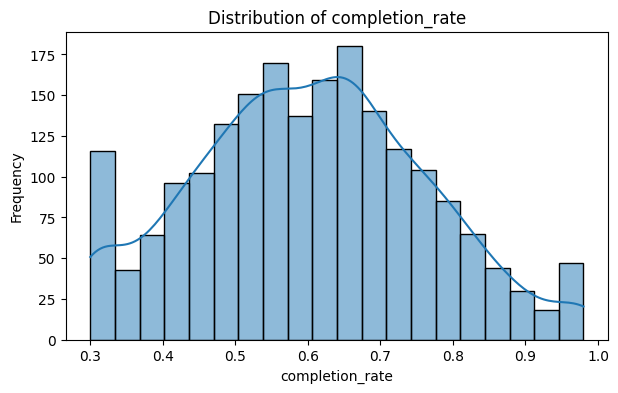

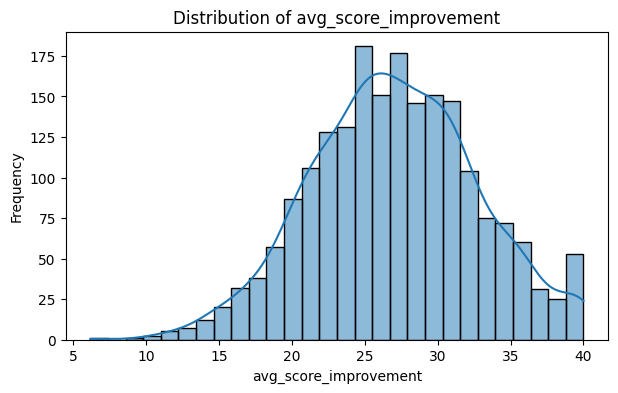

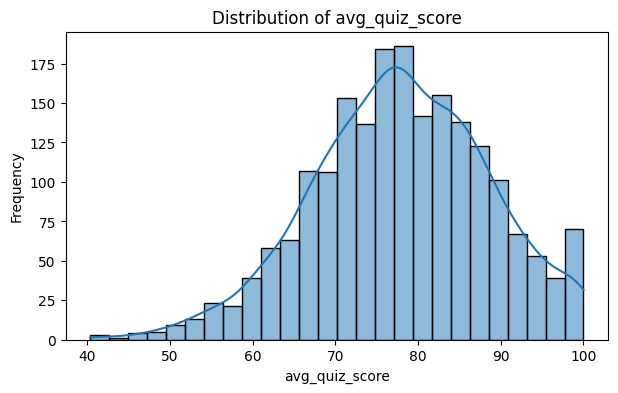

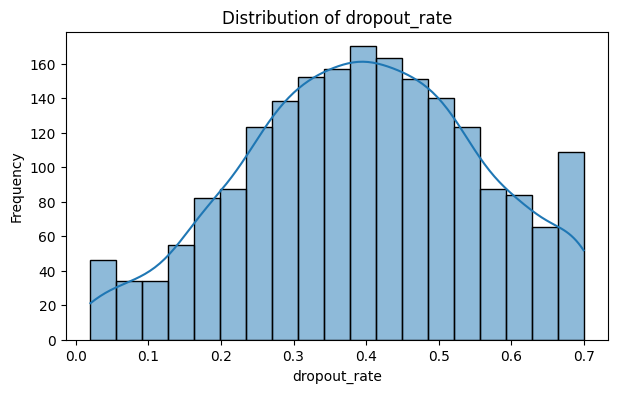

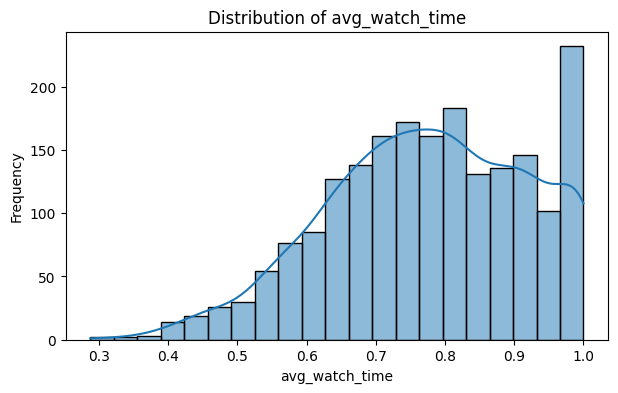

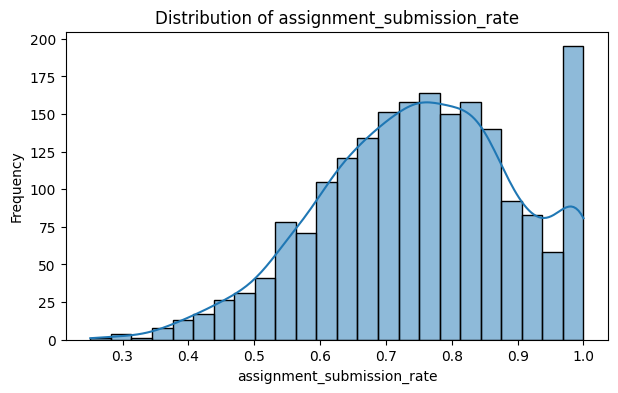

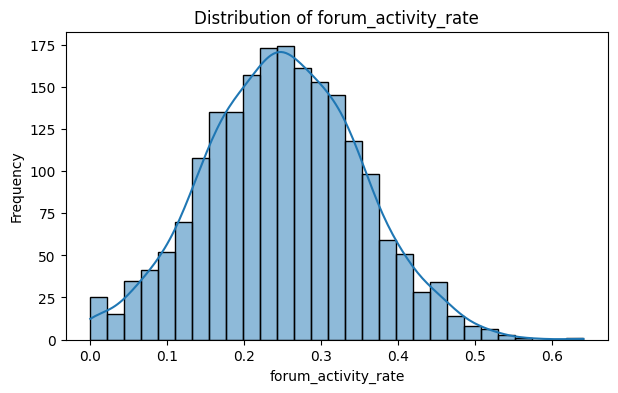

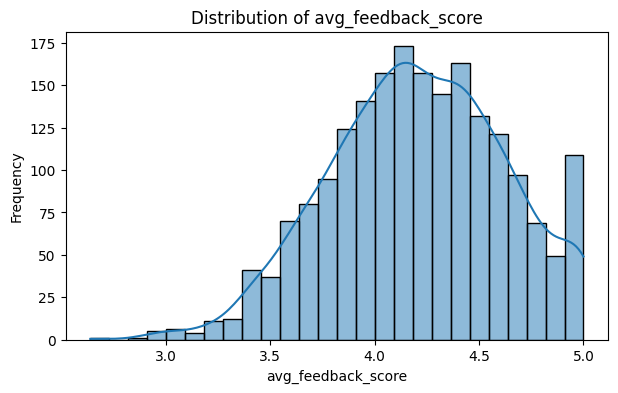

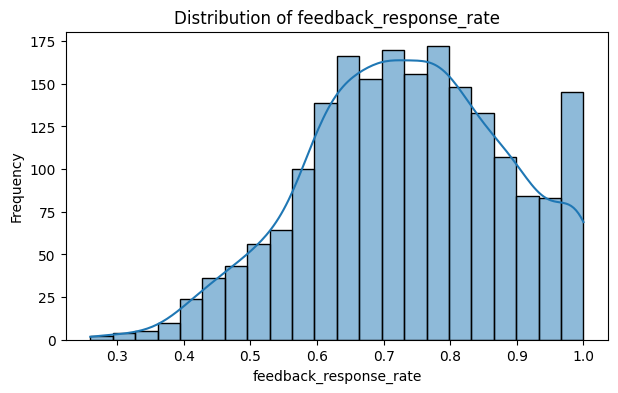

In [73]:
numeric_cols = [
    "completion_rate",
    "avg_score_improvement",
    "avg_quiz_score",
    "dropout_rate",
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate",
    "avg_feedback_score",
    "feedback_response_rate"
]

for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

NOw i will do oulier analysis

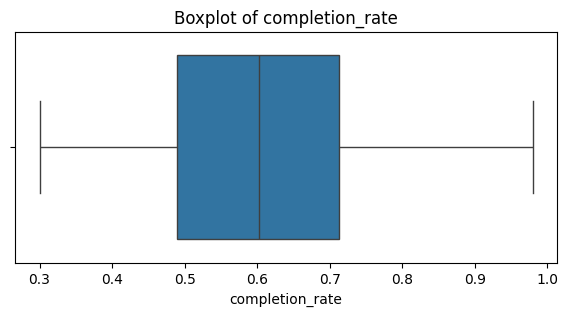

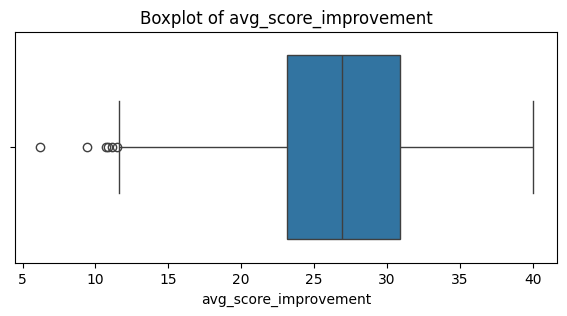

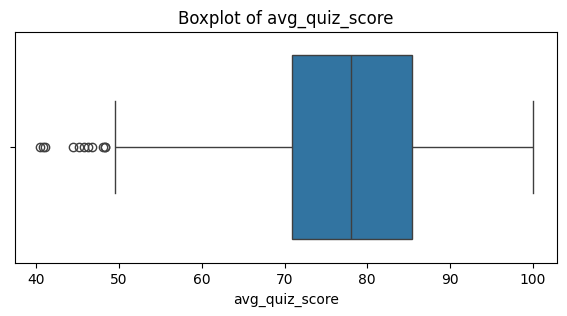

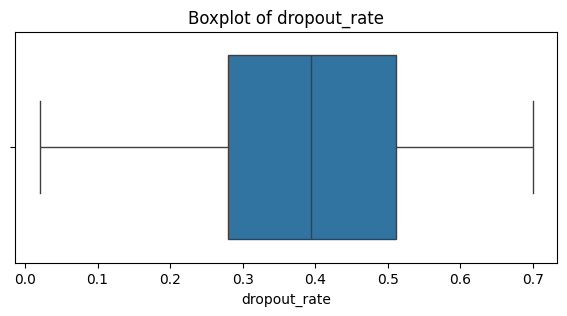

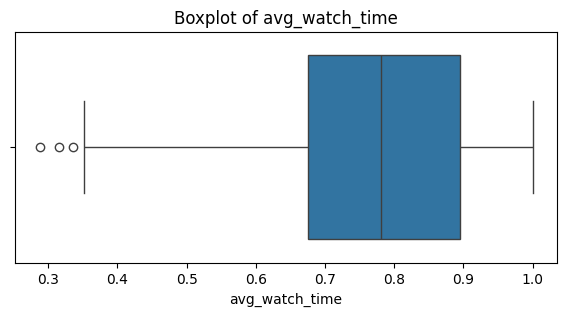

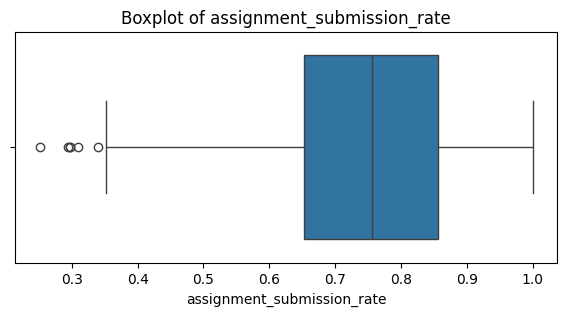

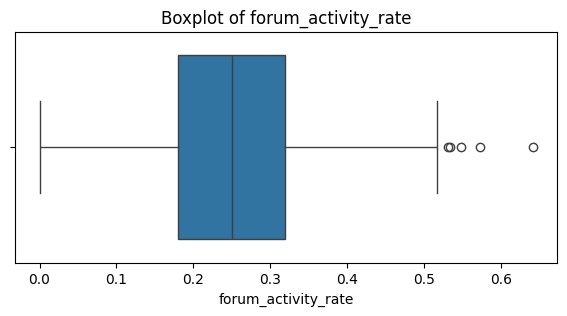

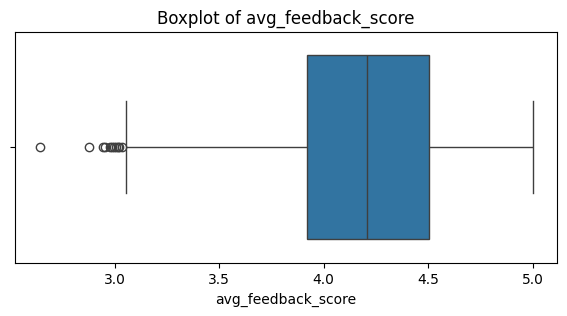

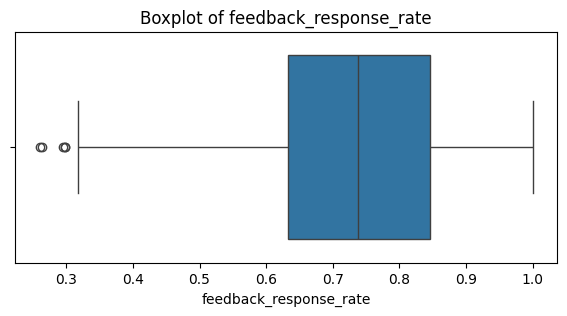

In [74]:
for col in numeric_cols:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

I used boxplots to check whether there are unusually high or low observations. I don't want to remove an observation just because it is an outlier.
In this problem, an unusual batch could actually be a real batch where learners performed much better or worse than usual.

Now i will see the correlation between all the numerical columns i am using ,i will plot the correlation matrix using the heatmap

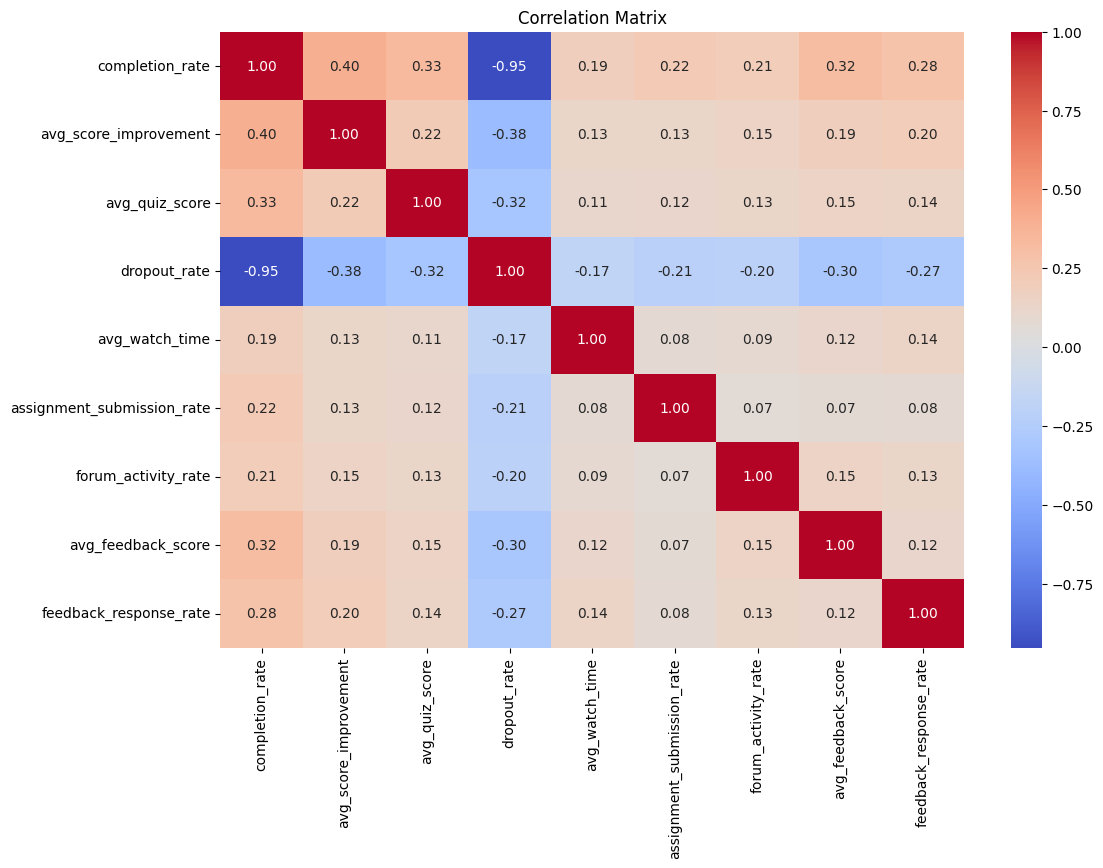

In [75]:
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

The Scale: The numbers range from -1 to +1.
+1.00 (Dark Red): Perfect positive relationship. If one goes up, the other definitely goes up.
0.00 (White/Light): No relationship at all. The variables don't affect each other.
-1.00 (Dark Blue): Perfect negative relationship. If one goes up, the other goes down (like completion_rate vs dropout_rate).
 this is how the heatmap works
 by considering these parameters we can anakyse heat map

I checked the correlations to see whether some variables were giving almost the same information. The strongest relationship is between completion rate and dropout rate, which makes sense because batches with more learners completing the course should generally have fewer learners dropping out.

At the same time, this is something I need to be careful about when creating the effectiveness score. If I give both variables a large weight, I could end up counting the same learner-retention signal twice

Now I have to find out Number of Batches per instrucctor

In [76]:
batch_counts = df.groupby("instructor_id")["batch_id"].count()
print("Number of Batches per Instructor:")
print(batch_counts)
batch_counts.describe()

Number of Batches per Instructor:
instructor_id
I_001    25
I_002    20
I_003    18
I_004    17
I_005    19
         ..
I_116    17
I_117    19
I_118    19
I_119    19
I_120    13
Name: batch_id, Length: 120, dtype: int64


,batch_id
count,120.000000
mean,16.666667
std,4.582270
min,7.000000
25%,13.750000
50%,17.000000
75%,19.000000
max,31.000000


In tis cell i am getting to know that there are tottal 120 instructor and how many batches are handled by each instructor individually

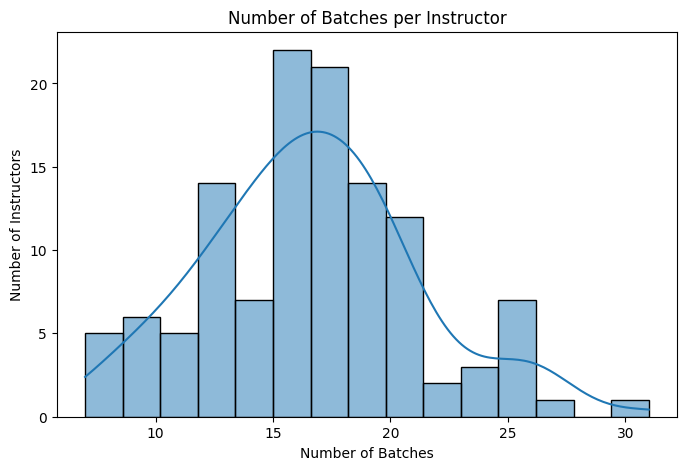

In [77]:
plt.figure(figsize=(8,5))

sns.histplot(batch_counts, bins=15, kde=True)

plt.title("Number of Batches per Instructor")
plt.xlabel("Number of Batches")
plt.ylabel("Number of Instructors")

plt.show()

I checked how many batches each instructor has because the original data is at batch level, but my final score needs to be at instructor level. An instructor with only a few batches may have an average that is more affected by individual batches, while an instructor with many batches has more observations behind the average. I will keep this in mind when I aggregate the data.

I decided to give more importance to learner outcomes because the main purpose of instructor effectiveness is to understand whether learners are actually completing the course and improving their performance. Engagement is also important because it shows learner participation, but high engagement alone does not necessarily mean that learners are learning effectively. I therefore gave engagement a slightly lower weight. Feedback is useful as an additional perspective, so I gave it 20%.

I use Min-Max Scaling to convert each metric to a 0-1 range.

For a metric where higher is better:

Normalized=
max(x)-min(x)/x-min(x)
	​


This means:

0 → lowest observed performance
1 → highest observed performance

In [78]:
from sklearn.preprocessing import MinMaxScaler

score_cols = [
    "completion_rate",
    "avg_score_improvement",
    "avg_quiz_score",
    "dropout_rate",
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate",
    "avg_feedback_score",
    "feedback_response_rate"
]

scaler = MinMaxScaler()

df_scaled = df.copy()

df_scaled[score_cols] = scaler.fit_transform(df[score_cols])
df_scaled[score_cols].head()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,0.000000,0.238373,0.556249,0.922681,0.683637,0.720811,0.169103,0.477227,0.369235
1,0.525324,0.493839,0.619419,0.595732,0.291198,0.998085,0.437599,1.000000,0.640690
2,0.000000,0.293382,0.657185,1.000000,0.968987,0.742683,0.322898,0.371797,0.569542
3,0.499274,0.534901,0.988179,0.462731,0.784601,0.391839,0.477913,0.664240,1.000000
4,0.334267,0.736459,0.989825,0.736911,0.884150,0.820915,0.393519,0.756886,0.590184


If we simply normalize dropout, a batch with a high dropout rate would get a high normalized score—which is the opposite of what we want.

So we'll reverse it:

Dropout Score=1-Normalized Dropout

In [79]:
df_scaled["dropout_score"] = 1 - df_scaled["dropout_rate"]
df_scaled[["dropout_rate", "dropout_score"]].head()

,dropout_rate,dropout_score
0,0.922681,7.731867e-02
1,0.595732,4.042678e-01
2,1.000000,-2.220446e-16
3,0.462731,5.372689e-01
4,0.736911,2.630895e-01


I have calculates Dropout seperately because it is the only metric where a lower value indicates better performance. After normalizing it, I reversed the value so that all the final score components follow the same direction: higher score always means better performance.

Now i will calculate the Effectiveness score for each category
1)Learner Outcome
2)Engagement
3)feedback
these are three categories

In [80]:
df_scaled["outcome_score"] = (
    0.25 * df_scaled["completion_rate"] +
    0.25 * df_scaled["avg_score_improvement"] +
    0.25 * df_scaled["avg_quiz_score"] +
    0.25 * df_scaled["dropout_score"]
)

In [81]:
df_scaled["engagement_score"] = (
    df_scaled["avg_watch_time"] +
    df_scaled["assignment_submission_rate"] +
    df_scaled["forum_activity_rate"]
) / 3

In [82]:
df_scaled["feedback_score"] = (
    df_scaled["avg_feedback_score"] +
    df_scaled["feedback_response_rate"]
) / 2

Here we will do sum of all the categories

In [83]:
df_scaled["effectiveness_score"] = (
    0.50 * df_scaled["outcome_score"] +
    0.30 * df_scaled["engagement_score"] +
    0.20 * df_scaled["feedback_score"]
)
df_scaled["effectiveness_score"].describe()

,effectiveness_score
count,2000.000000
mean,0.573165
std,0.112860
min,0.181882
25%,0.496176
50%,0.574845
75%,0.646576
max,0.918663


We got the effectivenss Score for the instructors
I first normalized all the metrics so that they were on the same 0–1 scale. I then created three separate scores for learner outcomes, engagement, and feedback. I gave learner outcomes 50% of the total score because they are the most direct indicators of whether learners are succeeding. Engagement contributes 30%, while feedback contributes 20%.

For dropout, I reversed the normalized value because lower dropout represents better instructor performance. Finally, I combined the three category scores to create one effectiveness score between 0 and 1.

If Instructor 101 taught 15 batches, how do we combine those 15 batch results into one instructor score?
 Now we will have to check batches per instructor

In [84]:
instructor_summary = df_scaled.groupby("instructor_id").agg(
    effectiveness_score=("effectiveness_score", "mean"),
    outcome_score=("outcome_score", "mean"),
    engagement_score=("engagement_score", "mean"),
    feedback_score=("feedback_score", "mean"),
    num_batches=("batch_id", "count")
).reset_index()

instructor_summary.head()


,instructor_id,effectiveness_score,outcome_score,engagement_score,feedback_score,num_batches
0,I_001,0.537324,0.486832,0.560951,0.628114,25
1,I_002,0.673072,0.675646,0.640758,0.715106,20
2,I_003,0.688608,0.692001,0.637652,0.756559,18
3,I_004,0.494478,0.394523,0.579959,0.616145,17
4,I_005,0.748861,0.795380,0.713739,0.685247,19


In [85]:
instructor_summary.shape

(120, 6)

In [86]:
low_threshold = instructor_summary["effectiveness_score"].quantile(0.33)
high_threshold = instructor_summary["effectiveness_score"].quantile(0.67)

print("Low threshold:", low_threshold)
print("High threshold:", high_threshold)

Low threshold: 0.5374056522515688
High threshold: 0.6086850938453212


In [87]:
def assign_tier(score):
    if score <= low_threshold:
        return "Low"
    elif score <= high_threshold:
        return "Medium"
    else:
        return "High"

instructor_summary["effectiveness_tier"] = (
    instructor_summary["effectiveness_score"]
    .apply(assign_tier)
)

In [88]:
instructor_summary["effectiveness_tier"].value_counts()
instructor_summary.groupby("effectiveness_tier")["effectiveness_score"].agg(
    ["count", "min", "mean", "max"]
)

,count,min,mean,max
effectiveness_tier,,,,
High,40,0.608748,0.677296,0.829650
Low,40,0.338706,0.468611,0.537324
Medium,40,0.537625,0.571435,0.608515


In [89]:
instructor_summary["effectiveness_tier"].value_counts(normalize=True) * 100

,proportion
effectiveness_tier,
Low,33.333333
High,33.333333
Medium,33.333333


Since the dataset does not provide predefined cutoffs for Low, Medium, and High effectiveness, I used the 33rd and 67th percentiles of the instructor-level effectiveness scores. This creates three relative performance groups and avoids choosing arbitrary thresholds. The tiers should therefore be interpreted as relative performance within this dataset rather than absolute measures of instructor quality.

In [90]:
instructor_summary["effectiveness_score"].describe()

,effectiveness_score
count,120.000000
mean,0.572447
std,0.097532
min,0.338706
25%,0.505125
50%,0.571484
75%,0.629490
max,0.829650


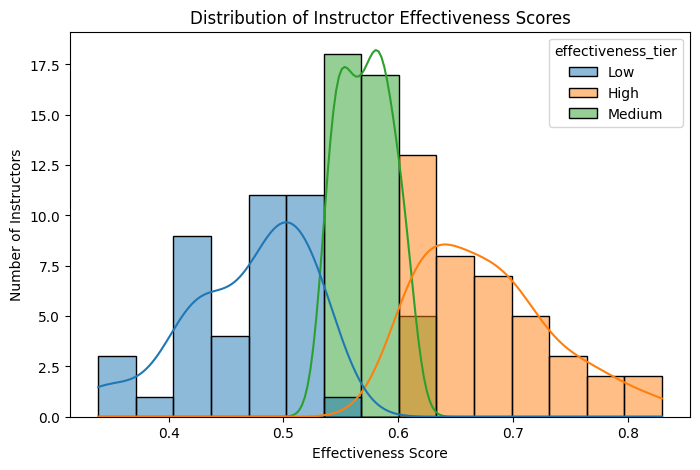

In [91]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=instructor_summary,
    x="effectiveness_score",
    hue="effectiveness_tier",
    bins=15,
    kde=True
)

plt.title("Distribution of Instructor Effectiveness Scores")
plt.xlabel("Effectiveness Score")
plt.ylabel("Number of Instructors")

plt.show()

I plotted the instructor-level effectiveness scores to see how the instructors are distributed across the score range. The scores are spread across the range rather than being concentrated at one value, which supports the use of different effectiveness tiers.

In [92]:
instructor_summary.sort_values(
    "effectiveness_score",
    ascending=False
).head(10)

,instructor_id,effectiveness_score,outcome_score,engagement_score,feedback_score,num_batches,effectiveness_tier
9,I_010,0.829650,0.890563,0.726446,0.832171,13,High
36,I_037,0.802264,0.858323,0.706448,0.805841,15,High
17,I_018,0.776801,0.809735,0.722889,0.775336,14,High
104,I_105,0.769606,0.809961,0.693010,0.783610,16,High
90,I_091,0.759094,0.822491,0.665003,0.741735,8,High
4,I_005,0.748861,0.795380,0.713739,0.685247,19,High
117,I_118,0.735749,0.765916,0.619048,0.835384,19,High
24,I_025,0.726727,0.755326,0.661000,0.753821,19,High
50,I_051,0.709059,0.730908,0.646923,0.747642,26,High
12,I_013,0.706360,0.739436,0.610399,0.767611,17,High


In [93]:
instructor_summary.sort_values(
    "effectiveness_score",
    ascending=True
).head(10)

,instructor_id,effectiveness_score,outcome_score,engagement_score,feedback_score,num_batches,effectiveness_tier
74,I_075,0.338706,0.223102,0.427258,0.494889,19,Low
43,I_044,0.339157,0.229129,0.445748,0.454337,15,Low
49,I_050,0.359365,0.251874,0.450859,0.490851,12,Low
112,I_113,0.392288,0.286031,0.497292,0.500423,26,Low
73,I_074,0.404466,0.302569,0.501353,0.513880,17,Low
66,I_067,0.417226,0.321617,0.529742,0.487473,14,Low
82,I_083,0.421466,0.343782,0.435066,0.595278,10,Low
37,I_038,0.424023,0.317098,0.509497,0.563123,20,Low
60,I_061,0.425939,0.326467,0.507410,0.552410,15,Low
35,I_036,0.427928,0.347876,0.495429,0.526807,21,Low


Now i Will be building the ML model  for that i have to check what are the columns will give us the  Required outcome

In [94]:
instructor_summary.columns

Index(['instructor_id', 'effectiveness_score', 'outcome_score',
       'engagement_score', 'feedback_score', 'num_batches',
       'effectiveness_tier'],
      dtype='object')

In [95]:
instructor_features = df_scaled.groupby("instructor_id").agg(
    completion_rate=("completion_rate", "mean"),
    avg_score_improvement=("avg_score_improvement", "mean"),
    avg_quiz_score=("avg_quiz_score", "mean"),
    dropout_rate=("dropout_rate", "mean"),
    avg_watch_time=("avg_watch_time", "mean"),
    assignment_submission_rate=("assignment_submission_rate", "mean"),
    forum_activity_rate=("forum_activity_rate", "mean"),
    avg_feedback_score=("avg_feedback_score", "mean"),
    feedback_response_rate=("feedback_response_rate", "mean"),
    num_batches=("batch_id", "count")
).reset_index()

In [96]:
instructor_ml = instructor_features.merge(
    instructor_summary[
        ["instructor_id", "effectiveness_score", "effectiveness_tier"]
    ],
    on="instructor_id",
    how="inner"
)

In [97]:
instructor_ml.shape

(120, 13)

In [98]:
instructor_ml.head()

,instructor_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,num_batches,effectiveness_score,effectiveness_tier
0,I_001,0.358658,0.605253,0.646055,0.662637,0.672327,0.635317,0.375209,0.668547,0.587682,25,0.537324,Low
1,I_002,0.633639,0.709411,0.693645,0.334109,0.771799,0.698745,0.451731,0.721621,0.708591,20,0.673072,High
2,I_003,0.688892,0.703843,0.691192,0.315924,0.745203,0.705706,0.462047,0.766972,0.746147,18,0.688608,High
3,I_004,0.232836,0.495047,0.625592,0.775384,0.709681,0.677277,0.352917,0.608662,0.623627,17,0.494478,Low
4,I_005,0.823158,0.780993,0.762270,0.184902,0.785317,0.835679,0.520220,0.662095,0.708399,19,0.748861,High


Our dataset is ready to build the ml model

In [99]:
feature_cols = [
    "completion_rate",
    "avg_score_improvement",
    "avg_quiz_score",
    "dropout_rate",
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate",
    "avg_feedback_score",
    "feedback_response_rate",
    "num_batches"
]

X = instructor_ml[feature_cols]
y = instructor_ml["effectiveness_tier"]

In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 96
Testing samples: 24


Model 1 — Logistic Regression
Model 2 — Decision Tree
Model 3 — Random Forest

1)Logistic Regression


In [101]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

In [102]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Accuracy: 0.9166666666666666

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.75      0.86         8
         Low       1.00      1.00      1.00         8
      Medium       0.80      1.00      0.89         8

    accuracy                           0.92        24
   macro avg       0.93      0.92      0.92        24
weighted avg       0.93      0.92      0.92        24



Model 2)Decision Tree

I chose a Decision Tree as the second model because it can capture non-linear relationships and is easier to interpret than many other machine learning models. It can also help me understand which features are being used to separate the Low, Medium, and High effectiveness groups.

In [103]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

decision_tree.fit(X_train, y_train)

y_pred_tree = decision_tree.predict(X_test)

In [104]:
from sklearn.metrics import accuracy_score, classification_report

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.875

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.88      0.93         8
         Low       0.88      0.88      0.88         8
      Medium       0.78      0.88      0.82         8

    accuracy                           0.88        24
   macro avg       0.88      0.88      0.88        24
weighted avg       0.88      0.88      0.88        24



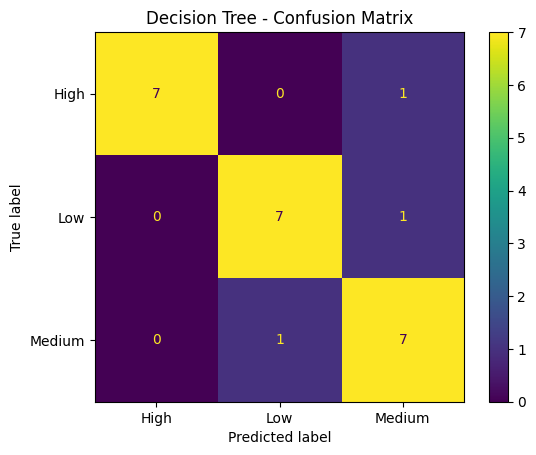

In [105]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tree
)

plt.title("Decision Tree - Confusion Matrix")
plt.show()

I used a maximum depth of 4 to keep the tree reasonably simple and reduce the chance of overfitting. Since the dataset contains only 120 instructors, I don't want the model to become unnecessarily complex and memorize the training data.

Model 3)Random Forest

In [106]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

In [107]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9166666666666666

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.88      0.93         8
         Low       1.00      0.88      0.93         8
      Medium       0.80      1.00      0.89         8

    accuracy                           0.92        24
   macro avg       0.93      0.92      0.92        24
weighted avg       0.93      0.92      0.92        24



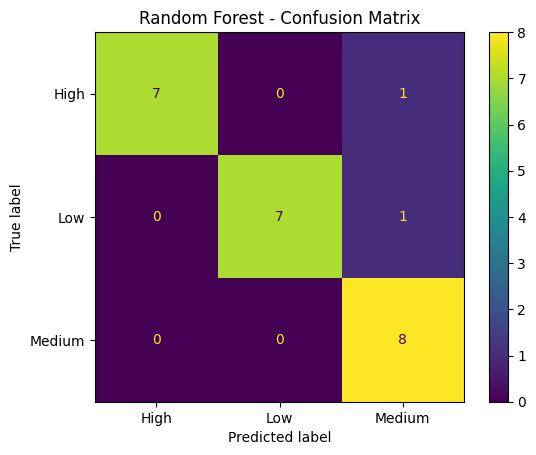

In [108]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

The confusion matrix shows that Random Forest correctly classified 22 out of 24 test observations. The only errors were two instructors from the High and Low categories being predicted as Medium. There were no cases where a High instructor was classified as Low or a Low instructor was classified as High.

I used Random Forest as the third model because it combines multiple decision trees instead of relying on a single tree. This can make the predictions more stable and can reduce the risk of overfitting. It is also useful for understanding which instructor-level features contribute most to the classification.

Compare al 3 models

In [109]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic, average="macro"),
        precision_score(y_test, y_pred_tree, average="macro"),
        precision_score(y_test, y_pred_rf, average="macro")
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic, average="macro"),
        recall_score(y_test, y_pred_tree, average="macro"),
        recall_score(y_test, y_pred_rf, average="macro")
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logistic, average="macro"),
        f1_score(y_test, y_pred_tree, average="macro"),
        f1_score(y_test, y_pred_rf, average="macro")
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.916667,0.933333,0.916667,0.915344
1,Decision Tree,0.875000,0.884259,0.875000,0.877288
2,Random Forest,0.916667,0.933333,0.916667,0.918519


In [110]:
results.sort_values("F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.916667,0.933333,0.916667,0.918519
0,Logistic Regression,0.916667,0.933333,0.916667,0.915344
1,Decision Tree,0.875000,0.884259,0.875000,0.877288


I compared Logistic Regression, Decision Tree, and Random Forest using accuracy, precision, recall, and F1-score. Random Forest gave the strongest overall performance, with 91.67% test accuracy and a macro F1-score of 0.92. It also performed well across all three effectiveness classes, so I selected it as the final model.

In [111]:
feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,completion_rate,0.304992
3,dropout_rate,0.205132
8,feedback_response_rate,0.161206
1,avg_score_improvement,0.092751
2,avg_quiz_score,0.078817
7,avg_feedback_score,0.057906
4,avg_watch_time,0.039009
6,forum_activity_rate,0.029599
5,assignment_submission_rate,0.025209
9,num_batches,0.005379


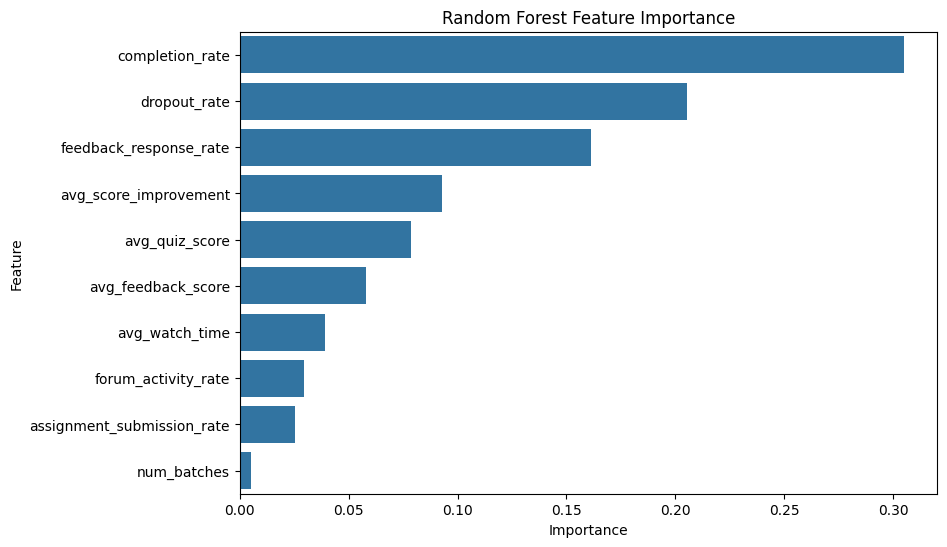

In [112]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# 1..Which features most influenced instructor effectiveness, and why?
#  Ans:
  Completion rate was the most important feature, followed by dropout rate and feedback response rate. This shows that learner retention, performance, and instructor responsiveness are important indicators of effectiveness. However, completion and dropout rate are strongly correlated, so their importance should be interpreted carefully.

# Which variables could be misleading or confounded?
# Ans
Some factors may be influenced by things other than the instructor. For example, watch time can depend on course difficulty, while assignment submission and forum activity can depend on learner motivation. Course type, learner background, and batch size can also affect the results.

# How could the model fail in real-world usage?

The model may not perform equally well on new courses, instructors, or learner groups. It could also give misleading results if course difficulty or learner motivation is different from the training data. Also, the test dataset is relatively small, so the 91.67% accuracy should not be treated as a guaranteed real-world performance.


# 4. What additional data would improve the analysis?

I would add course difficulty, batch size, learner experience, instructor experience, teaching method, and detailed learner feedback. Data collected over a longer period would also help check whether instructor performance is consistent over time.



# 5. Should this model be used for instructor performance evaluation?

I would use the model as a supporting tool, not as the only basis for evaluating instructors. The model can identify useful patterns, but human judgment is still needed because learner behaviour, course difficulty, and other factors can affect the results.